# 拓展：用 NumPy 反向传播训练 make_moons

把实践2的手写反向传播，替换掉 Task1 中 `loss.backward()` 自动求的梯度，在完整的 make_moons 数据集上做**全量（batch）梯度下降**训练。

为了和 Task1 公平对比，除了梯度来源，其余全部保持同口径：

| | Task1 (PyTorch) | 本实验 (NumPy) |
|---|---|---|
| 数据 | make_moons(n=1000, noise=0.2, seed=42)，600/200/200 划分 | 完全相同 |
| 结构 | 2 → 16 → 8 → 1（ReLU） | 完全相同 |
| 损失 | BCEWithLogitsLoss | 数学等价：dL/dZ = σ(Z) − y |
| 优化器 | Adam, lr=1e-3 | **全量梯度下降（朴素 GD）** |
| 轮数 | 1000 epoch | 1000 epoch |

反向公式（两层网络，样本数 m=600，logit 记 Z3）：

- dZ3 = (σ(Z3) − y) / m
- dW3 = A2ᵀ @ dZ3，db3 = dZ3 列求和
- dZ2 = (dZ3 @ W3ᵀ) ⊙ (Z2 > 0)
- dW2 = A1ᵀ @ dZ2，db2 = dZ2 列求和
- dZ1 = (dZ2 @ W2ᵀ) ⊙ (Z1 > 0)
- dW1 = Xᵀ @ dZ1，db1 = dZ1 列求和
- 更新：W ← W − lr · dW


In [1]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

SEED = 42
X, y = make_moons(n_samples=1000, noise=0.2, random_state=SEED)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=SEED, stratify=y_train)
y_train = y_train.reshape(-1, 1).astype(float)
y_val = y_val.reshape(-1, 1).astype(float)
y_test = y_test.reshape(-1, 1).astype(float)
print("Train", X_train.shape, "Val", X_val.shape, "Test", X_test.shape)


Train (600, 2) Val (200, 2) Test (200, 2)


In [2]:
def init_params(rng, sizes=(2, 16, 8, 1)):
    params = {}
    for i in range(1, len(sizes)):
        params[f"W{i}"] = rng.normal(0, np.sqrt(2 / sizes[i - 1]), size=(sizes[i - 1], sizes[i]))
        params[f"b{i}"] = np.zeros(sizes[i])
    return params

def forward(X, p):
    Z1 = X @ p["W1"] + p["b1"]; A1 = np.maximum(0, Z1)
    Z2 = A1 @ p["W2"] + p["b2"]; A2 = np.maximum(0, Z2)
    Z3 = A2 @ p["W3"] + p["b3"]          # logit
    return Z1, A1, Z2, A2, Z3

def backward(X, y, cache, p):
    Z1, A1, Z2, A2, Z3 = cache
    m = X.shape[0]
    P = 1 / (1 + np.exp(-Z3))
    dZ3 = (P - y) / m                     # sigmoid+BCE 融合，且除以 batch 大小
    grads = {}
    grads["W3"] = A2.T @ dZ3; grads["b3"] = dZ3.sum(axis=0)
    dZ2 = (dZ3 @ p["W3"].T) * (Z2 > 0)
    grads["W2"] = A1.T @ dZ2; grads["b2"] = dZ2.sum(axis=0)
    dZ1 = (dZ2 @ p["W2"].T) * (Z1 > 0)
    grads["W1"] = X.T @ dZ1; grads["b1"] = dZ1.sum(axis=0)
    return grads

def bce_with_logits(Z, y):
    # 数值稳定版 BCEWithLogits：max(Z,0) - Z*y + log(1+exp(-|Z|))，再取平均
    return np.mean(np.maximum(Z, 0) - Z * y + np.log(1 + np.exp(-np.abs(Z))))

def accuracy(Z, y):
    return ((Z > 0).astype(float) == y).mean()


In [3]:
import time

def train_full_batch(lr, epochs=1000, seed=0, verbose=True):
    rng = np.random.default_rng(seed)
    p = init_params(rng)
    hist = {"train_loss": [], "val_loss": [], "val_acc": []}
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        cache = forward(X_train, p)
        loss = bce_with_logits(cache[4], y_train)
        grads = backward(X_train, y_train, cache, p)
        for k in p:
            p[k] -= lr * grads[k]

        vcache = forward(X_val, p)
        vloss = bce_with_logits(vcache[4], y_val)
        hist["train_loss"].append(loss)
        hist["val_loss"].append(vloss)
        hist["val_acc"].append(accuracy(vcache[4], y_val))
        if verbose and epoch % 100 == 0:
            print(f"Epoch {epoch:4d} | train loss {loss:.4f} | val loss {vloss:.4f} | val acc {hist['val_acc'][-1]:.4f}")
    dt = time.time() - t0
    return p, hist, dt

p1, hist1, dt1 = train_full_batch(lr=0.5)
print(f"\nlr=0.5 训练耗时 {dt1:.2f}s | 最终 val acc {hist1['val_acc'][-1]:.4f}")


Epoch  100 | train loss 0.1697 | val loss 0.2123 | val acc 0.9100
Epoch  200 | train loss 0.0886 | val loss 0.1150 | val acc 0.9600
Epoch  300 | train loss 0.0815 | val loss 0.1011 | val acc 0.9600
Epoch  400 | train loss 0.0778 | val loss 0.0960 | val acc 0.9600
Epoch  500 | train loss 0.0738 | val loss 0.0911 | val acc 0.9650
Epoch  600 | train loss 0.0717 | val loss 0.0896 | val acc 0.9650
Epoch  700 | train loss 0.0668 | val loss 0.0819 | val acc 0.9750
Epoch  800 | train loss 0.0649 | val loss 0.0787 | val acc 0.9800
Epoch  900 | train loss 0.0645 | val loss 0.0786 | val acc 0.9750
Epoch 1000 | train loss 0.0644 | val loss 0.0775 | val acc 0.9750

lr=0.5 训练耗时 0.34s | 最终 val acc 0.9750


## 学习率对比

全量梯度下降没有 Adam 的自适应步长，学习率是唯一的手动旋钮。下面用一组学习率各跑 1000 epoch：


In [4]:
results = {}
for lr in [0.05, 0.2, 0.5, 1.0, 2.0]:
    _, h, dt = train_full_batch(lr=lr, verbose=False)
    results[lr] = h
    print(f"lr={lr:<4} | val acc {h['val_acc'][-1]:.4f} | 最终 train loss {h['train_loss'][-1]:.4f} | 耗时 {dt:.2f}s")


lr=0.05 | val acc 0.9100 | 最终 train loss 0.1700 | 耗时 0.33s
lr=0.2  | val acc 0.9600 | 最终 train loss 0.0703 | 耗时 0.34s
lr=0.5  | val acc 0.9750 | 最终 train loss 0.0644 | 耗时 0.34s
lr=1.0  | val acc 0.9750 | 最终 train loss 0.0623 | 耗时 0.33s
lr=2.0  | val acc 0.9650 | 最终 train loss 0.0524 | 耗时 0.34s


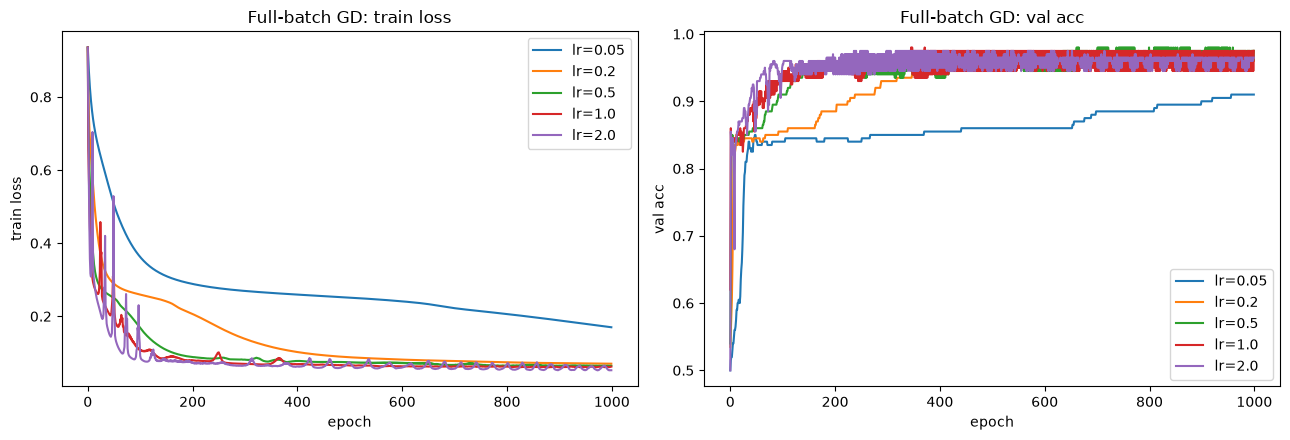

saved: extend-lr-compare.png


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for lr, h in results.items():
    axes[0].plot(h["train_loss"], label=f"lr={lr}")
    axes[1].plot(h["val_acc"], label=f"lr={lr}")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("train loss"); axes[0].set_title("Full-batch GD: train loss")
axes[0].legend()
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("val acc"); axes[1].set_title("Full-batch GD: val acc")
axes[1].legend()
plt.tight_layout()
plt.savefig("extend-lr-compare.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved: extend-lr-compare.png")


## 用最优学习率训练 + 学习曲线

选上面表现最好的学习率正式训练，画 loss / accuracy 曲线：


best lr = 0.5
Epoch  100 | train loss 0.1697 | val loss 0.2123 | val acc 0.9100
Epoch  200 | train loss 0.0886 | val loss 0.1150 | val acc 0.9600
Epoch  300 | train loss 0.0815 | val loss 0.1011 | val acc 0.9600
Epoch  400 | train loss 0.0778 | val loss 0.0960 | val acc 0.9600
Epoch  500 | train loss 0.0738 | val loss 0.0911 | val acc 0.9650
Epoch  600 | train loss 0.0717 | val loss 0.0896 | val acc 0.9650
Epoch  700 | train loss 0.0668 | val loss 0.0819 | val acc 0.9750
Epoch  800 | train loss 0.0649 | val loss 0.0787 | val acc 0.9800
Epoch  900 | train loss 0.0645 | val loss 0.0786 | val acc 0.9750
Epoch 1000 | train loss 0.0644 | val loss 0.0775 | val acc 0.9750


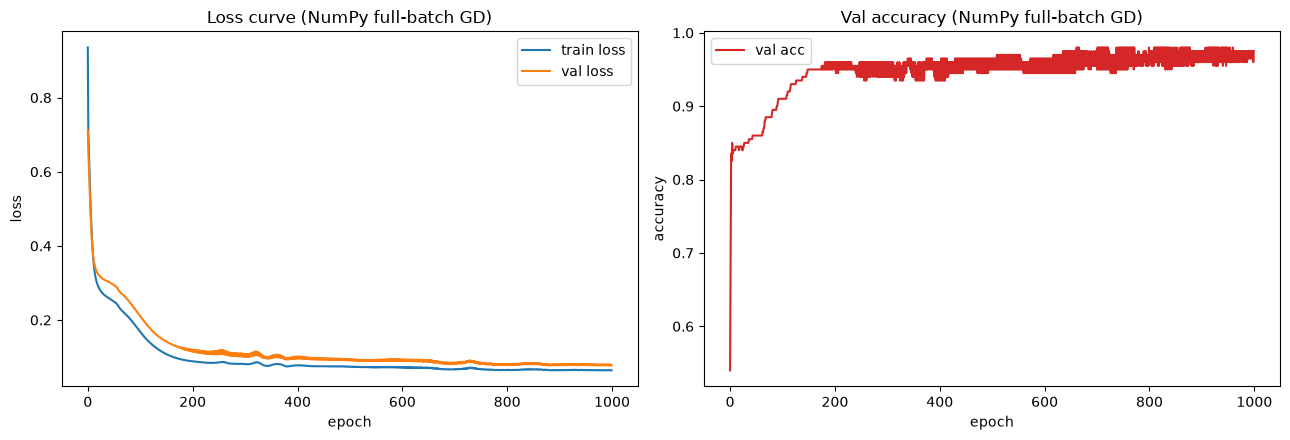

训练耗时 0.33s | 最终 val acc 0.9750


In [6]:
best_lr = max(results, key=lambda lr: results[lr]["val_acc"][-1])
print("best lr =", best_lr)
p_best, hist_best, dt_best = train_full_batch(lr=best_lr)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(hist_best["train_loss"], label="train loss")
axes[0].plot(hist_best["val_loss"], label="val loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].set_title("Loss curve (NumPy full-batch GD)")
axes[0].legend()
axes[1].plot(hist_best["val_acc"], label="val acc", color="tab:red")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].set_title("Val accuracy (NumPy full-batch GD)")
axes[1].legend()
plt.tight_layout()
plt.savefig("extend-curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"训练耗时 {dt_best:.2f}s | 最终 val acc {hist_best['val_acc'][-1]:.4f}")


In [7]:
tcache = forward(X_test, p_best)
test_acc = accuracy(tcache[4], y_test)
print(f"NumPy 全量GD  test acc: {test_acc:.4f}")
print(f"Task1 PyTorch test acc: 0.9850 (Adam, 同结构同数据)")


NumPy 全量GD  test acc: 0.9900
Task1 PyTorch test acc: 0.9850 (Adam, 同结构同数据)


## 决策边界对比

左：NumPy 手写反向 + 全量 GD；右：Task1 的 PyTorch MLP（Adam）。两者结构相同，只有优化器和梯度来源不同：


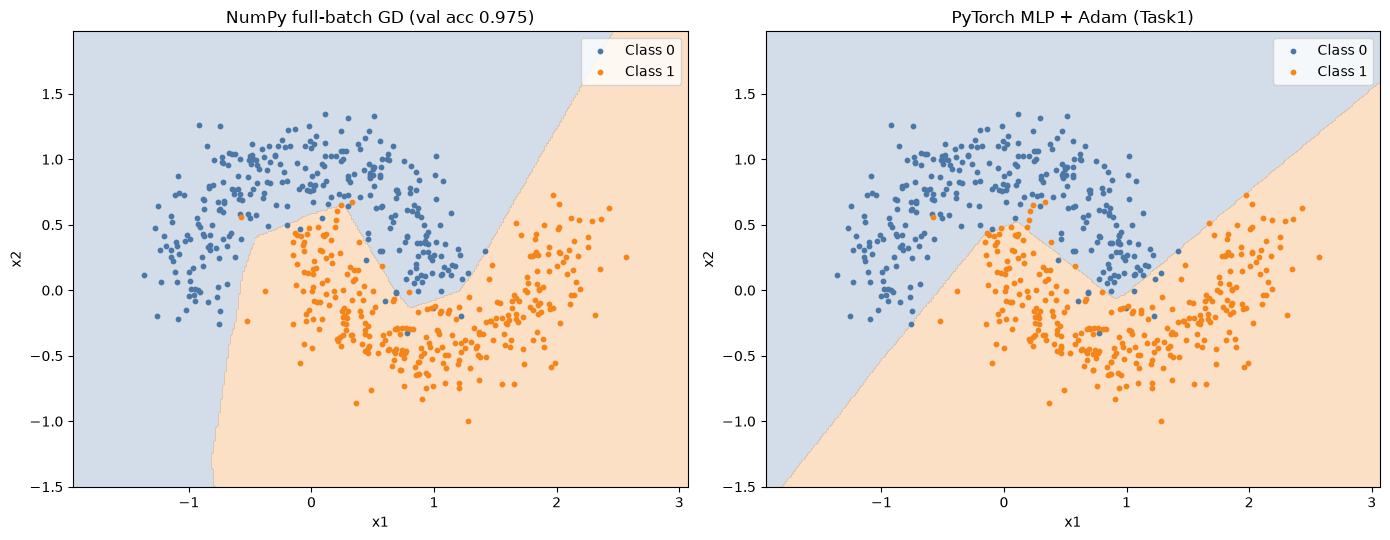

saved: extend-decision-boundary.png


In [8]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

zz_np = forward(grid, p_best)[4].reshape(xx.shape)

import torch
torch.manual_seed(SEED)
mlp = torch.nn.Sequential(
    torch.nn.Linear(2, 16), torch.nn.ReLU(),
    torch.nn.Linear(16, 8), torch.nn.ReLU(),
    torch.nn.Linear(8, 1))
crit = torch.nn.BCEWithLogitsLoss()
opt = torch.optim.Adam(mlp.parameters(), lr=1e-3)
Xtr = torch.tensor(X_train, dtype=torch.float32)
ytr = torch.tensor(y_train, dtype=torch.float32)
for epoch in range(1000):
    opt.zero_grad()
    loss = crit(mlp(Xtr), ytr)
    loss.backward()
    opt.step()
with torch.no_grad():
    zz_pt = mlp(torch.tensor(grid, dtype=torch.float32)).numpy().reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, zz, title in [(axes[0], zz_np > 0, f"NumPy full-batch GD (val acc {hist_best['val_acc'][-1]:.3f})"),
                      (axes[1], zz_pt > 0, "PyTorch MLP + Adam (Task1)")]:
    ax.contourf(xx, yy, zz.astype(float), levels=1, alpha=0.25, colors=["#4C78A8", "#F58518"])
    ax.scatter(X_train[y_train.ravel() == 0, 0], X_train[y_train.ravel() == 0, 1], s=10, c="#4C78A8", label="Class 0")
    ax.scatter(X_train[y_train.ravel() == 1, 0], X_train[y_train.ravel() == 1, 1], s=10, c="#F58518", label="Class 1")
    ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_title(title); ax.legend()
plt.tight_layout()
plt.savefig("extend-decision-boundary.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved: extend-decision-boundary.png")


## 附：反向传播正确性再确认

为了确认扩展用的手写反向没有笔误，随机参数下与 PyTorch autograd 对一次梯度（全量 600 样本）：


In [9]:
rng = np.random.default_rng(7)
p_chk = init_params(rng)
cache_chk = forward(X_train, p_chk)
grads_np = backward(X_train, y_train, cache_chk, p_chk)

tX = torch.tensor(X_train, dtype=torch.float64)
ty = torch.tensor(y_train, dtype=torch.float64)
tp = {}
for k, v in p_chk.items():
    tp[k] = torch.tensor(v, dtype=torch.float64, requires_grad=True)
Z1 = tX @ tp["W1"] + tp["b1"]; A1 = torch.relu(Z1)
Z2 = A1 @ tp["W2"] + tp["b2"]; A2 = torch.relu(Z2)
Z3 = A2 @ tp["W3"] + tp["b3"]
torch.nn.functional.binary_cross_entropy_with_logits(Z3, ty).backward()

ok = True
for k in ["W1", "b1", "W2", "b2", "W3", "b3"]:
    err = np.abs(grads_np[k] - tp[k].grad.numpy()).max()
    ok = ok and err < 1e-10
    print(f"d{k}: max abs err = {err:.2e}")
print("全量梯度与 autograd 一致:", ok)


dW1: max abs err = 2.78e-17
db1: max abs err = 1.53e-16
dW2: max abs err = 2.78e-17
db2: max abs err = 2.78e-17
dW3: max abs err = 1.39e-17
db3: max abs err = 1.39e-17
全量梯度与 autograd 一致: True
